Python 3.5.6 |Anaconda, Inc.| (default, Jun  4 2021, 13:57:47) 
[GCC 7.5.0] on linux


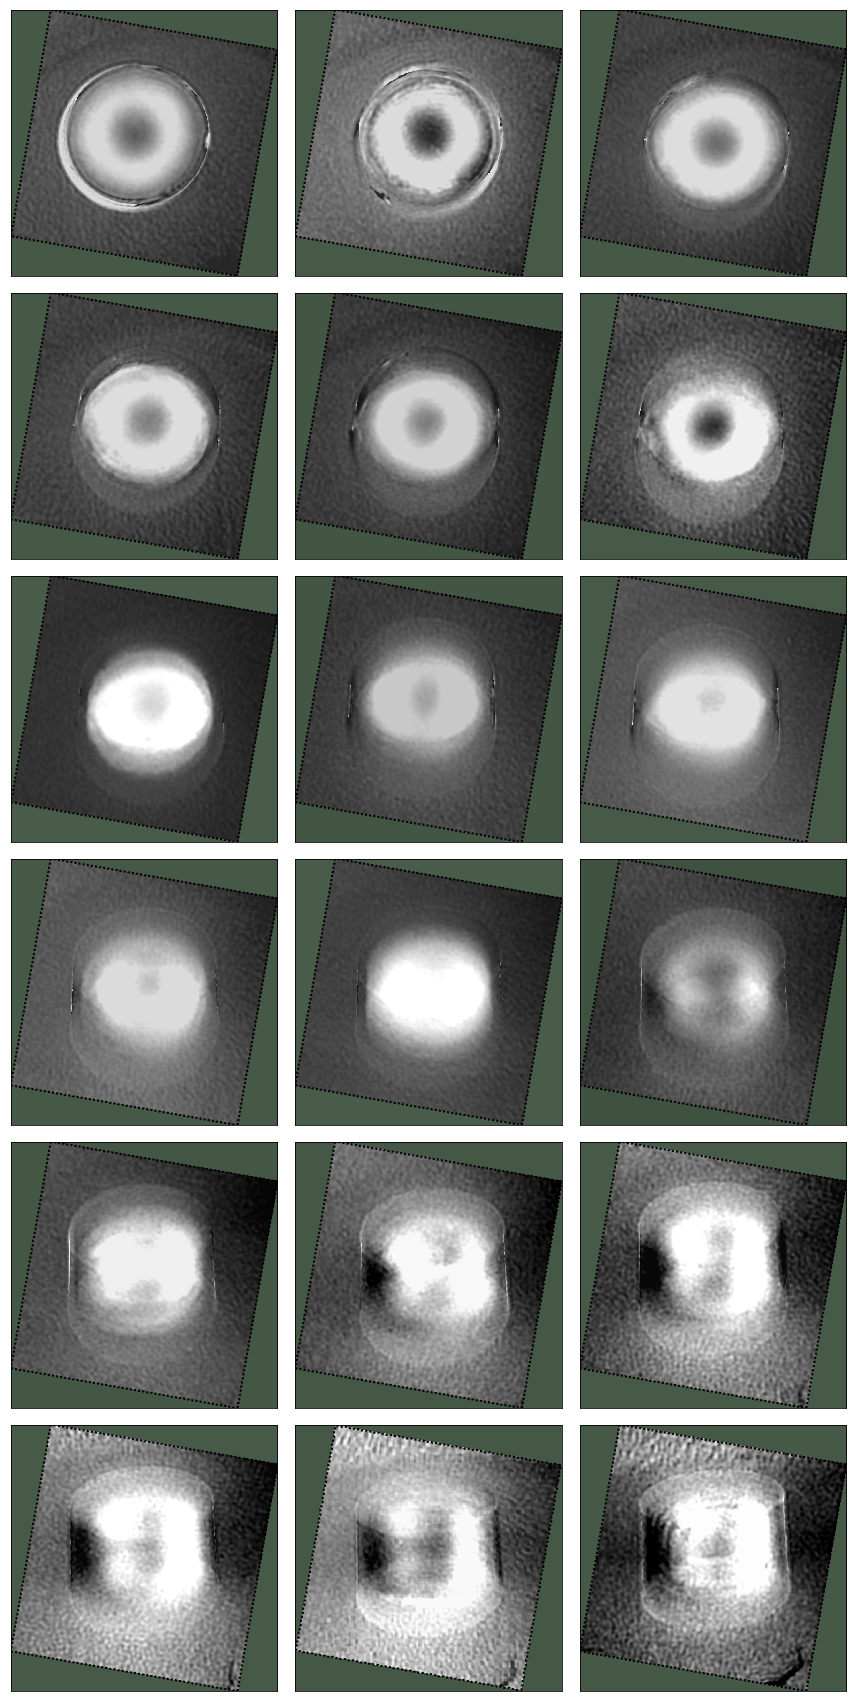

In [58]:
import sys
sys.path.extend(['/home/zhaoy/packages/Pyramid']) 
print('Python %s on %s' % (sys.version, sys.platform))

import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import hyperspy.api as hs
import pyramid as pr
from scipy.ndimage import gaussian_filter 

def remap_data(data, old_min, old_max, target_min=-0.5, target_max=2.0):
    data_clipped = np.clip(data, old_min, old_max)
    data_mapped = (data_clipped - old_min) / (old_max - old_min) * (target_max - target_min) + target_min
    return data_mapped

angles = [0, -5.2, -8.2, -12.2, -16, -20, -24, -28, -32, -36, -40.8, -44, -46.9, -50, -54, -58, -61, -65.2]
fig1 = plt.figure(figsize=(12,24))
ax1 = {}
phasemaps = []
TARGET_MIN = 0.5
TARGET_MAX = -0.5

for i, angle in enumerate(angles):
    tilt = angle
    magdata = hs.load('/home/zhaoy/studio/target-skyrmion/dataset/phase_all/M_phase_{:g}.dm3'.format(angle))
    pm = magdata.data
    current_vmin = np.percentile(pm, 5)
    current_vmax = np.percentile(pm, 95)
    pm_normalized = remap_data(pm, current_vmin, current_vmax, TARGET_MIN, TARGET_MAX)
    phasemaps.append(pr.PhaseMap(a=1, phase=pm_normalized))
    if i == 16:
        phasemaps[i] = phasemaps[i].crop((28, 28))
    else:
        phasemaps[i] = phasemaps[i].crop((120, 120))
    
    phasemaps[i] = phasemaps[i].rotate(10)

    ax1[i+1] = fig1.add_subplot(6, 3, i+1, aspect='equal')
    ax1[i+1].get_xaxis().set_visible(False)
    ax1[i+1].get_yaxis().set_visible(False)
    
    phasemaps[i].plot_phase(
        axis=ax1[i+1],
        scalebar=False,
        cbar=False,
        cmap='gray',
        symmetric=False)
    plt.tight_layout(h_pad=0.4)

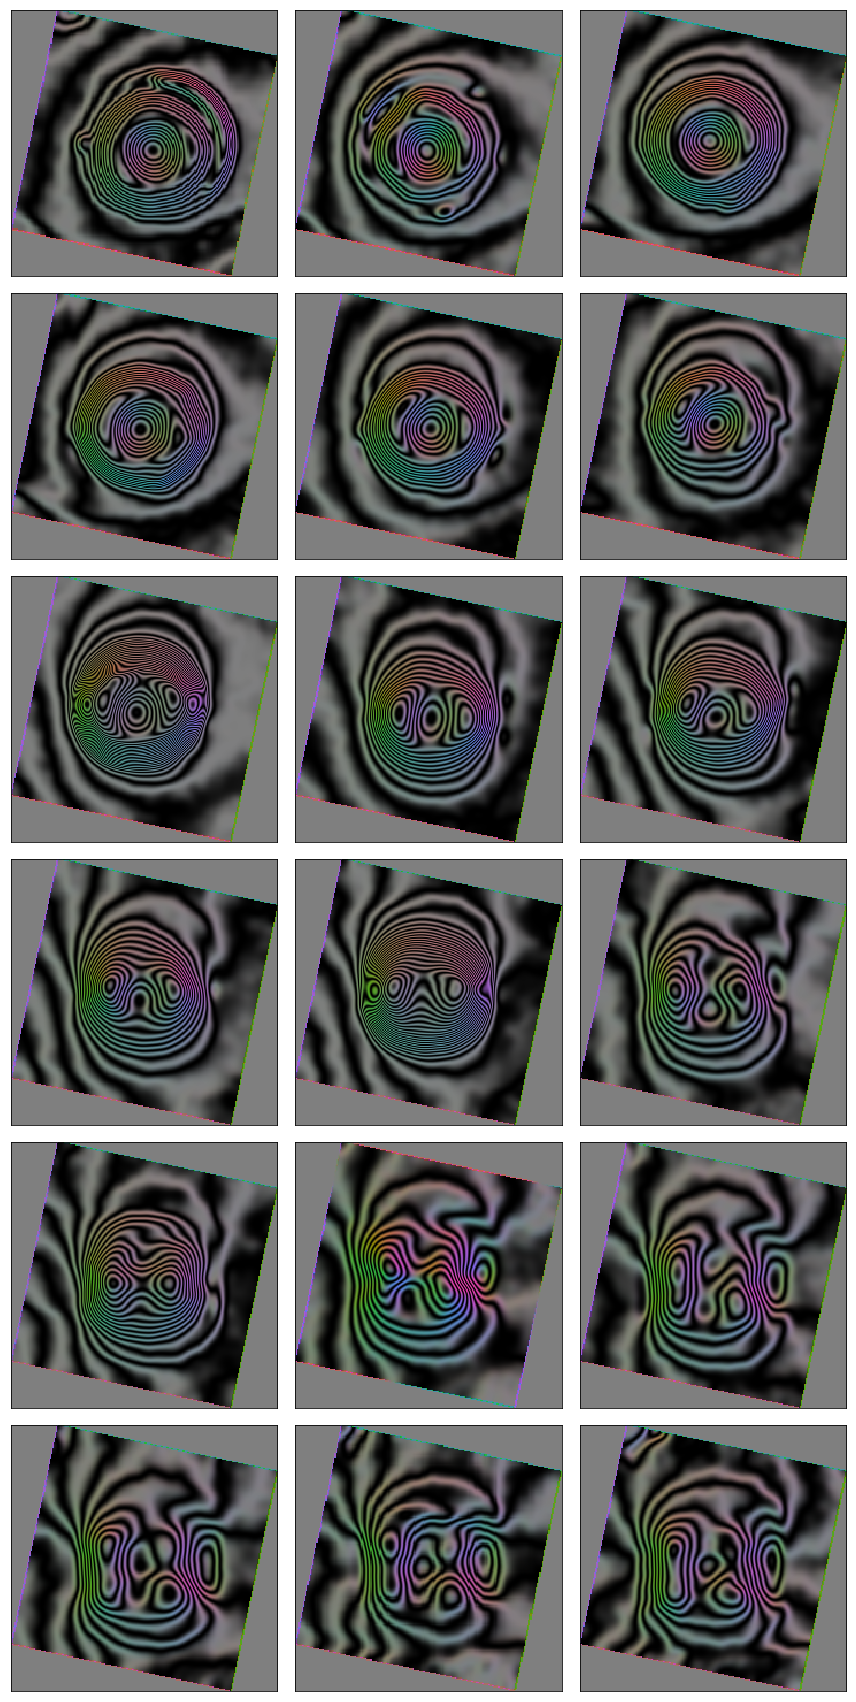

In [ ]:
fig2 = plt.figure(figsize=(12,24))
ax2 = {}
phaseholos = []
for i, angle in enumerate(angles):
    tilt = angle
    magdata = hs.load('/home/zhaoy/studio/target-skyrmion/dataset/phase_all/M_phase_{:g}.dm3'.format(angle))
    pm = magdata.data
    phaseholos.append(pr.PhaseMap(a=1, phase=pm))
    if i == 16:
        phaseholos[i] = phaseholos[i].crop((28,28))
        phaseholos[i].phase = gaussian_filter(phaseholos[i].phase, sigma=5)
    else:
        phaseholos[i] = phaseholos[i].crop((120,120))
        phaseholos[i].phase = gaussian_filter(phaseholos[i].phase, sigma=19)
        phaseholos[i] = phaseholos[i].scale_down(2)
    phaseholos[i] = phaseholos[i].rotate(12).flip('u').flip('v')

    ax2[i+1] = fig2.add_subplot(6, 3, i+1, aspect='equal')
    ax2[i+1].get_xaxis().set_visible(False)
    ax2[i+1].get_yaxis().set_visible(False)
    phaseholos[i].plot_holo(axis=ax2[i+1],gain=40,scalebar=False,colorwheel=False,note='{}'.format(tilt))
    plt.tight_layout(h_pad=0.4)